<a href="https://colab.research.google.com/github/latifahaljurayyan/insightApp/blob/main/Copy_of_copy_of_copy_of_gp__4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# @title
!pip install google_play_scraper

In [27]:
from google_play_scraper import reviews, Sort
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
apps = {
    "Amazon": "com.amazon.mShop.android.shopping",
    "Shein": "com.zzkko",
    "AliExpress": "com.alibaba.aliexpresshd",
    "Noon": "com.noon.buyerapp",
    "Trendyol": "trendyol.com"
}


In [29]:
def label_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

In [30]:
all_reviews = []

for app_name, app_id in apps.items():
    print(f"Fetching reviews for {app_name}...")

    result, _ = reviews(
        app_id,
        lang="en",
        country="us",
        sort=Sort.NEWEST,
        count=3000
    )

    for r in result:
        all_reviews.append({
            "app_name": app_name,
            "review_text": r["content"],
            "rating": r["score"],
            "sentiment_label": label_sentiment(r["score"])
        })

Fetching reviews for Amazon...
Fetching reviews for Shein...
Fetching reviews for AliExpress...
Fetching reviews for Noon...
Fetching reviews for Trendyol...


In [31]:
df = pd.DataFrame(all_reviews)
df.head()


,app_name,review_text,rating,sentiment_label
0,Amazon,I have been with Amazon since 2020 and order a...,5,Positive
1,Amazon,no problems,5,Positive
2,Amazon,"Latest update is AWFUL, as usual for any Amazo...",1,Negative
3,Amazon,it works as it should.,5,Positive
4,Amazon,Almost impossible to get live help. terrible c...,1,Negative


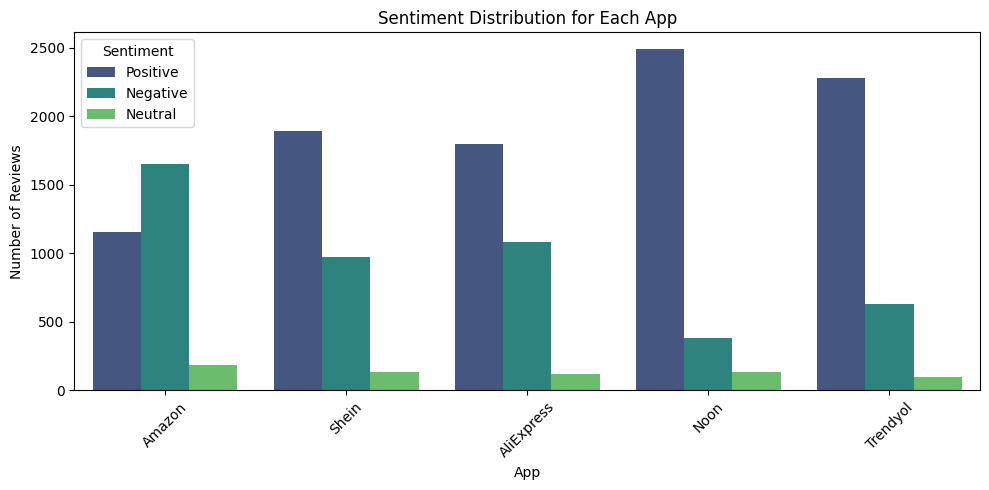

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

df_before = df.copy()
plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_before,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [33]:
print ("Before: \n", df_before["sentiment_label"]. value_counts ())

Before: 
 sentiment_label
Positive    9616
Negative    4715
Neutral      669
Name: count, dtype: int64


In [34]:
df = df[df["review_text"].astype(str).str.contains(r"[A-Za-z]", na=False)].copy()
df["review_text"] = df["review_text"].astype(str)
df = df[df["review_text"].str.strip().ne("")].copy()

print("After language/empty filtering:", len(df))

After language/empty filtering: 14444


In [35]:
import re



def clean_text(text):

    text = re.sub(r"http\S+", "", str(text))

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = text.lower()

    return text



df["clean_review"] = df["review_text"].apply(clean_text)

In [36]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [37]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,I have been with Amazon since 2020 and order a...,i have been with amazon since and order almos...
1,no problems,no problems
2,"Latest update is AWFUL, as usual for any Amazo...",latest update is awful as usual for any amazon...
3,it works as it should.,it works as it should
4,Almost impossible to get live help. terrible c...,almost impossible to get live help terrible cu...
5,bug,bug
6,so futerated as I went pick up packages I had ...,so futerated as i went pick up packages i had ...
7,awesome,awesome
8,great to do shopping,great to do shopping
9,my go to spot,my go to spot


In [38]:
import nltk
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [39]:
df["Tokens"]= df["clean_review"].apply(word_tokenize)
df[[ "clean_review","Tokens"]].head(5)

,clean_review,Tokens
0,i have been with amazon since and order almos...,"[i, have, been, with, amazon, since, and, orde..."
1,no problems,"[no, problems]"
2,latest update is awful as usual for any amazon...,"[latest, update, is, awful, as, usual, for, an..."
3,it works as it should,"[it, works, as, it, should]"
4,almost impossible to get live help terrible cu...,"[almost, impossible, to, get, live, help, terr..."


In [40]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

r
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["Tokens_No_Stopwords"] = df["Tokens"].apply(remove_stopwords)


def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["Tokens_No_Stopwords_Lemmatized"] = df["Tokens_No_Stopwords"].apply(lemmatize_tokens)


df[["Tokens", "Tokens_No_Stopwords", "Tokens_No_Stopwords_Lemmatized"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Tokens,Tokens_No_Stopwords,Tokens_No_Stopwords_Lemmatized
0,"[i, have, been, with, amazon, since, and, orde...","[amazon, since, order, almost, dailyno, retail...","[amazon, since, order, almost, dailyno, retail..."
1,"[no, problems]",[problems],[problem]
2,"[latest, update, is, awful, as, usual, for, an...","[latest, update, awful, usual, amazon, operate...","[latest, update, awful, usual, amazon, operate..."
3,"[it, works, as, it, should]",[works],[work]
4,"[almost, impossible, to, get, live, help, terr...","[almost, impossible, get, live, help, terrible...","[almost, impossible, get, live, help, terrible..."


In [41]:
df['tokens_str'] = df['Tokens_No_Stopwords_Lemmatized'].apply(lambda x: ' '.join(x))
df = df.drop_duplicates(subset='tokens_str', keep='first')

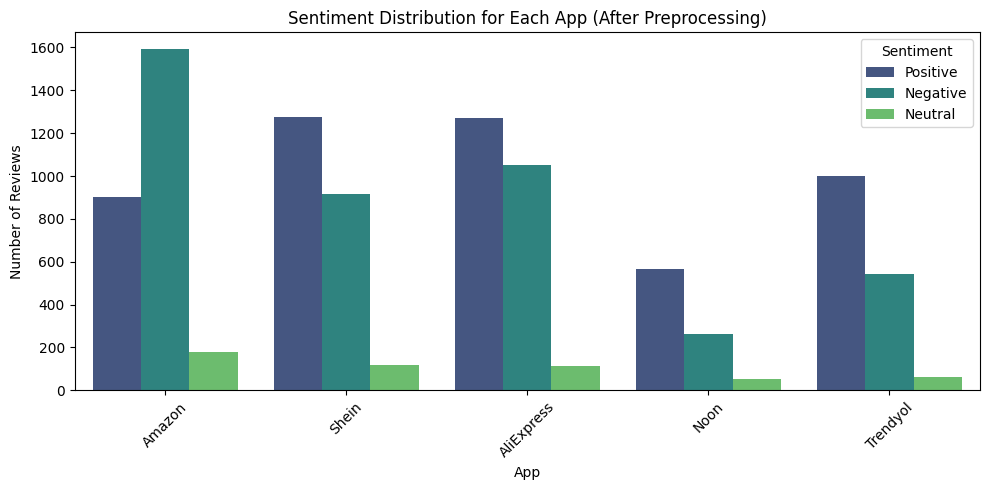

In [42]:
df_after = df.copy()

plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_after,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (After Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [43]:

print("\nAfter:\n", df_after["sentiment_label"].value_counts() )


After:
 sentiment_label
Positive    5011
Negative    4367
Neutral      524
Name: count, dtype: int64


In [44]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [45]:
from google.colab import files
files.download("google_play_app_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
X_text = df['tokens_str']
y = df['sentiment_label']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

In [47]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: sentiment_label
Positive    4009
Negative    3493
Neutral      419
Name: count, dtype: int64
After SMOTE: sentiment_label
Negative    4009
Positive    4009
Neutral     4009
Name: count, dtype: int64


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_predictions))

Random Forest Accuracy: 0.8364462392730944
Classification Report:
               precision    recall  f1-score   support

    Negative       0.82      0.88      0.85       874
     Neutral       0.15      0.06      0.08       105
    Positive       0.88      0.88      0.88      1002

    accuracy                           0.84      1981
   macro avg       0.62      0.61      0.60      1981
weighted avg       0.81      0.84      0.82      1981

Confusion Matrix:
 [[771  13  90]
 [ 69   6  30]
 [101  21 880]]


In [49]:
from sklearn.tree import DecisionTreeClassifier




dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train_resampled, y_train_resampled)


y_pred = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7364967188288744

Classification Report:

              precision    recall  f1-score   support

    Negative       0.76      0.73      0.75       874
     Neutral       0.09      0.14      0.11       105
    Positive       0.82      0.81      0.81      1002

    accuracy                           0.74      1981
   macro avg       0.56      0.56      0.56      1981
weighted avg       0.76      0.74      0.75      1981

Confusion Matrix:
 [[637 104 133]
 [ 51  15  39]
 [147  48 807]]


In [51]:
# SUPPORT VECTOR MACHINE (SVM)

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_SVM = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_SVM)

print("SVM Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_SVM))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_SVM))


SVM Accuracy: 79.05 %

Classification Report:
               precision    recall  f1-score   support

    Negative       0.85      0.83      0.84       874
     Neutral       0.09      0.20      0.12       105
    Positive       0.92      0.82      0.86      1002

    accuracy                           0.79      1981
   macro avg       0.62      0.62      0.61      1981
weighted avg       0.85      0.79      0.82      1981

Confusion Matrix:
 [[728 100  46]
 [ 59  21  25]
 [ 68 117 817]]


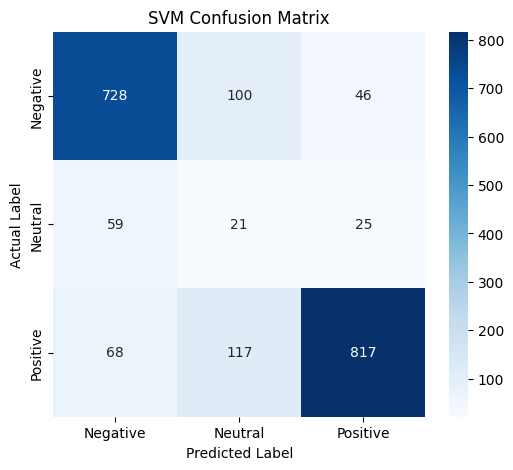

In [52]:

#  Confusion Matrix Graph FOR SVM

cm = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [53]:
print(set(y_pred_SVM))

{'Neutral', 'Positive', 'Negative'}


In [54]:
from sklearn.naive_bayes import MultinomialNB


nb_model = MultinomialNB()


nb_model.fit(X_train_resampled, y_train_resampled)


y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8001009591115599

Classification Report:
               precision    recall  f1-score   support

    Negative       0.83      0.84      0.83       874
     Neutral       0.13      0.27      0.17       105
    Positive       0.94      0.82      0.88      1002

    accuracy                           0.80      1981
   macro avg       0.63      0.64      0.63      1981
weighted avg       0.85      0.80      0.82      1981

Confusion Matrix:
 [[732 105  37]
 [ 58  28  19]
 [ 94  83 825]]


In [55]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train_encoded)


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_balanced, y_train_balanced)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:32:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.795557799091368

Classification Report:

              precision    recall  f1-score   support

    Negative       0.84      0.83      0.84       874
     Neutral       0.10      0.19      0.13       105
    Positive       0.90      0.83      0.86      1002

    accuracy                           0.80      1981
   macro avg       0.61      0.62      0.61      1981
weighted avg       0.83      0.80      0.81      1981

Confusion Matrix:

[[727  81  66]
 [ 58  20  27]
 [ 76  97 829]]
